In [ ]:
import gzip
import os
import pathlib
import tempfile
from concurrent.futures import ThreadPoolExecutor, as_completed
from io import StringIO, BytesIO

import earthaccess
import geopandas as gpd
import holoviews as hv
import hvplot.pandas
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import shapely
import requests
import rioxarray as rxr
import xarray as xr
from tqdm.notebook import tqdm
import utilities as util
import glob
import cartopy.crs as ccrs
import cartopy.feature as cfeature

import h5netcdf
import contextily as cx
import hvplot.xarray
import zipfile
import importlib
import download as dwld

importlib.reload(dwld)

data_dir = pathlib.Path().cwd().parent / 'data'
swot_path = data_dir / 'usgs_swot_data' / 'swot_timeseries_for_usgs_nodes.csv'
mrms_path_flag = data_dir / 'usgs_mrms_data' 
usgs_path = data_dir / 'usgs_stage_data'
start_time = '2023-01-01T00:00:00Z'
end_time = '2026-03-01T00:00:00Z'
precip_dir =  data_dir / 'pass_level_work/MRMS_precip'
os.makedirs(precip_dir, exist_ok=True)
precip_path = data_dir / 'pass_level_work/MRMS_precip/pass_{pass_no}_MRMS_{var_name}.csv'


In [2]:
# Ensure that the pass is being properly picked up
passes = ['341']
potential_tiles = ['227R', '228R', '229R']
river_results = []
for p in passes:
    print(p)
    river_results += earthaccess.search_data(
    short_name='SWOT_L2_HR_PIXC_2.0',
    temporal=('2023-02-01 00:00:00', '2026-03-15 23:59:59'),
    granule_name=f'*PIXC*_*_{p}_228R*',
    # bounding_box=(-125, 24, -66.5, 45)  # CONUS
    bounding_box=(-72.75, 41.25, -72.3, 42)
)

341


In [3]:
river_results[0]['umm']['SpatialExtent']['HorizontalSpatialDomain']['Track']['Passes'][0]['Tiles'][0]

'228R'

In [4]:
tiles = [item['umm']['SpatialExtent']['HorizontalSpatialDomain']['Track']['Passes'][0]['Tiles'][0] 
               for item in river_results]

In [5]:
np.unique(tiles)

array(['228R'], dtype='<U4')

In [6]:
end_times = [item['umm']['TemporalExtent']['RangeDateTime']['EndingDateTime'] 
               for item in river_results]
end_times=np.unique(pd.to_datetime(end_times).tz_convert("UTC").floor("2min"))

In [7]:
download_index = 17
test_download = river_results[download_index]
output_dir = './data_downloads/pixc_downloads'
os.makedirs(output_dir, exist_ok=True)
test =earthaccess.download(test_download, output_dir)


QUEUEING TASKS | :   0%|          | 0/1 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/1 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/1 [00:00<?, ?it/s]

In [8]:
test

[PosixPath('data_downloads/pixc_downloads/SWOT_L2_HR_PIXC_020_341_228R_20240901T200012_20240901T200023_PIC0_01.nc')]

In [9]:
ds_PIXC = xr.open_dataset(test[0], group = 'pixel_cloud', engine='h5netcdf').load()
 # Land and coastal pixels

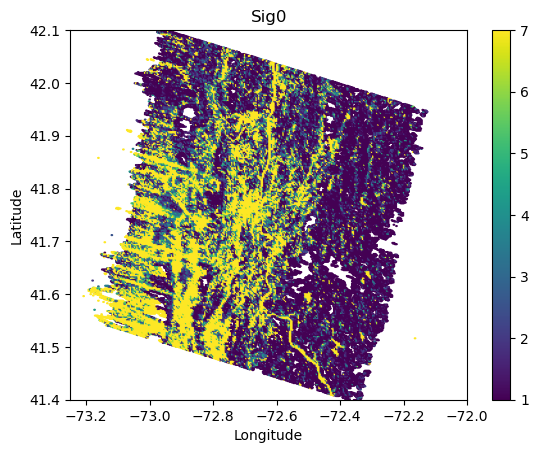

In [12]:
mask = (ds_PIXC.classification > 0) 
plt.hexbin(ds_PIXC.longitude[mask], ds_PIXC.latitude[mask], 
           C=ds_PIXC.sig0[mask], gridsize=500, reduce_C_function=np.mean)
# Reduce range of colorbar to focus on typical sig0 values
# plt.clim(-10, 30)
plt.clim(1,7)
plt.xlim(-73.25, -72)
plt.ylim(41.4,42.1)
plt.colorbar()
# Label the colorbar
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Sig0')
plt.show()

Text(0.5, 1.0, 'Prior Water Probability')

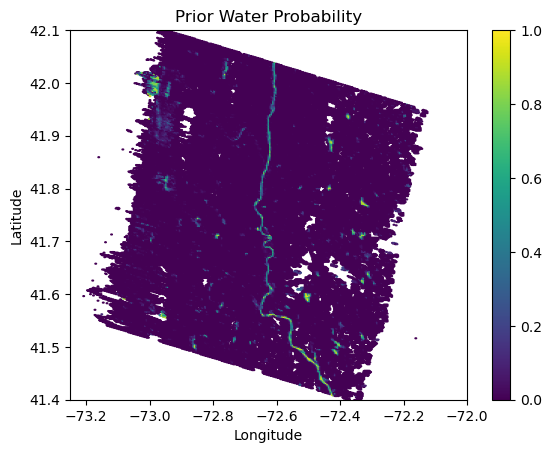

In [13]:
mask = (ds_PIXC.classification > 0) 
plt.hexbin(ds_PIXC.longitude[mask], ds_PIXC.latitude[mask], 
           C=ds_PIXC.prior_water_prob[mask], gridsize=500, reduce_C_function=np.mean)
# Reduce range of colorbar to focus on typical sig0 values
# plt.clim(-10, 30)
# plt.clim(0,50)
plt.clim(0,1)
plt.xlim(-73.25, -72)
plt.ylim(41.4,42.1)
plt.colorbar()
# Label the colorbar
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Prior Water Probability')

Text(0.5, 1.0, 'Classification')

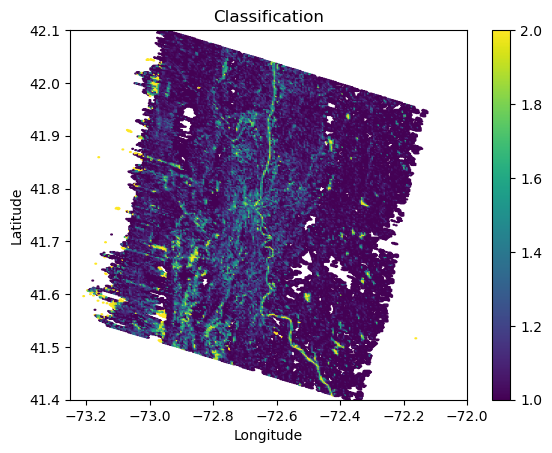

In [24]:
land_mask = np.where((ds_PIXC.classification>0))
# Reclassify values of 1 and 2 to 1 and greater than 2 to 2 for better visualization
adjusted_classification = xr.where(ds_PIXC.classification <=2, 1, 2)
plt.hexbin(adjusted_classification.longitude, adjusted_classification.latitude, 
           C=adjusted_classification, gridsize=500, reduce_C_function=np.mean)
# Reduce range of colorbar to focus on typical sig0 values
# plt.clim(-10, 30)
plt.clim(1,2)
plt.xlim(-73.25, -72)
plt.ylim(41.4,42.1)
plt.colorbar()
# Label the colorbar
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Classification')

In [22]:
adjusted_classification

<xarray.DataArray 'classification' (points: 6599537)> Size: 53MB
array([1, 1, 1, ..., 1, 1, 1], shape=(6599537,))
Coordinates:
    latitude   (points) float64 53MB 41.53 41.52 41.52 ... 41.95 41.95 41.95
    longitude  (points) float64 53MB -73.05 -73.05 -73.04 ... -72.13 -72.13
Dimensions without coordinates: points

In [18]:
adjusted_classification

array([1, 1, 1, ..., 1, 1, 1], shape=(6599537,))

In [25]:
import time
def fetch_raw_mrms_time_lat(dt, coords = [-80,-79,41,42],var_name='PrecipRate_00.00', hourly=False, already_utc=False):
    ## Build MRMS URL
    # print(dt)
    min_lon, max_lon, min_lat, max_lat = coords
    # Convert to UTC just in case
    if not already_utc:
        dt_utm0 = dt.tz_localize('UTC')
    else:
        dt_utm0 = dt
    # Get date components
    year, month, day = dt_utm0.year, dt_utm0.month, dt_utm0.day
    hour, minute = dt_utm0.hour, dt_utm0.minute
    # Round down to nearest even minute (MRMS data is every 2 minutes)
    if hourly:
        mrms_minute = 0  # Use the hour only
    else:
        # Round down to nearest even minute
        mrms_minute = (minute // 2) * 2
    # Format MRMS URL
    mrms_url = (
        "https://noaa-mrms-pds.s3.amazonaws.com/CONUS"
        f"/{var_name}"
        f"/{year}{month:02d}{day:02d}"
        f"/MRMS_{var_name}"
        f"_{year}{month:02d}{day:02d}-{hour:02d}{mrms_minute:02d}00"
        ".grib2.gz"
    )
    # print(mrms_url)
    # Download the MRMS data
    start_time = time.time()
    try:
        response = requests.get(mrms_url)
        if response.status_code != 200:
            print(f"Failed to download MRMS data for {dt_utm0}: "
                f"{response.status_code}")
            return pd.DataFrame(columns=['node_id', 'mrms_time', var_name])

        # Read the GRIB2 data from the gzipped content
        with gzip.open(BytesIO(response.content), 'rb') as gz:
            grib_bytes = gz.read()

        # Write to a temporary .grib2 file
        with tempfile.NamedTemporaryFile(suffix=".grib2", delete=False) as tmp:
            tmp.write(grib_bytes)
            tmp_path = tmp.name

        # Read it with xarray + cfgrib
        ds = xr.open_dataset(tmp.name, engine='cfgrib')
        
        end_time = time.time()
        # print(f"Downloaded test MRMS data for {dt_utm0} in {end_time - start_time:.2f} seconds")
        
        ds_var_name = list(ds.data_vars)[0]
        ds['longitude'] = (ds.longitude + 180) % 360 - 180
        return ds[ds_var_name].sel(longitude=slice(min_lon, max_lon), latitude=slice(max_lat, min_lat))
    except Exception as e:
        print(f"Error processing MRMS data for {dt_utm0}: {e}")
        return pd.DataFrame(columns=['node_id', 'mrms_time', var_name])

In [29]:
coords = [-73.25, -72, 41.4,42.1]
mrmrs_data = [fetch_raw_mrms_time_lat(end_time, coords=coords, already_utc=True) for end_time in end_times]
# test = fetch_raw_mrms_time_lat(pd.to_datetime(ds_PIXC.illumination_time.values.max()), coords=[-69.7,-68.4,50.2,51])

In [33]:
mrmrs_data[17].valid_time.values

np.datetime64('2024-09-22T16:44:00.000000000')

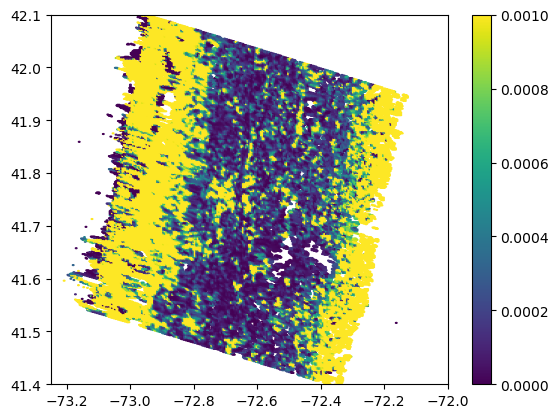

In [28]:
mask = (ds_PIXC.classification > 0) 
# plt.fi
plt.hexbin(ds_PIXC.longitude[mask], ds_PIXC.latitude[mask], 
           C=ds_PIXC.missed_detection_rate[mask], gridsize=500, reduce_C_function=np.mean)
# Reduce range of colorbar to focus on typical sig0 values
# plt.clim(-10, 30)
plt.clim(0,0.001)
plt.xlim(-73.25, -72)
plt.ylim(41.4,42.1)
plt.colorbar()

/opt/anaconda3/envs/swot/lib/python3.11/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/opt/anaconda3/envs/swot/lib/python3.11/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)


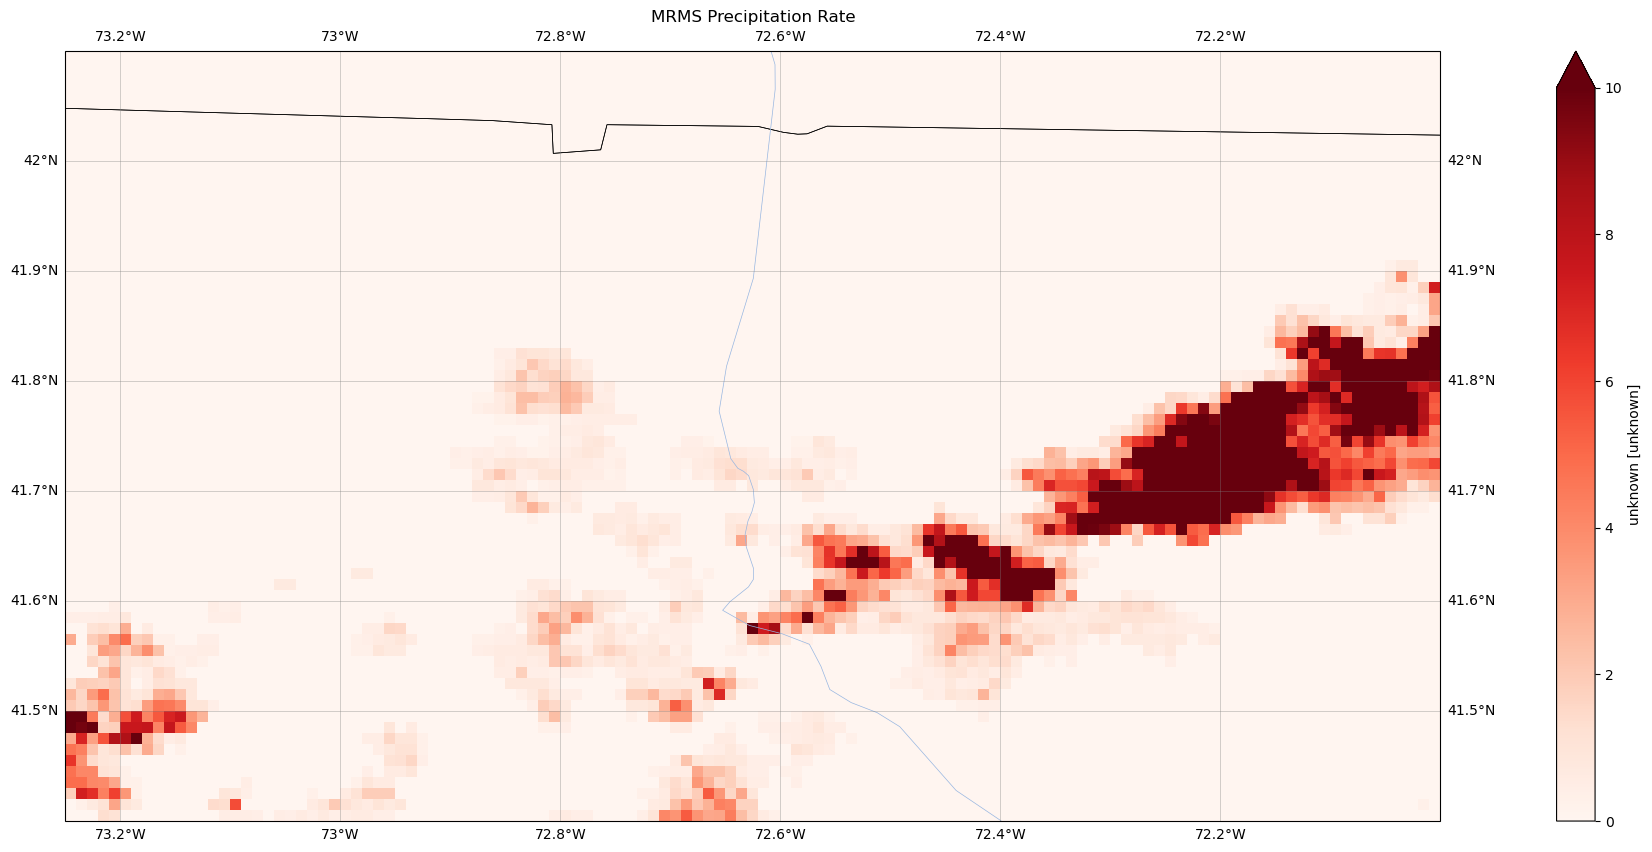

In [37]:
mrms_data_plot = mrmrs_data[16]
fig = plt.figure(figsize=(30, 10))
ax = plt.axes(projection=ccrs.PlateCarree())
# test_data = mrmrs_data[0]

mrms_data_plot.plot(ax=ax, transform=ccrs.PlateCarree(), vmin=0,vmax=10, cmap="Reds")
# ds_PIXC.plot.scatter(x='longitude', y='latitude', hue='sig0', ax=ax, transform=ccrs.PlateCarree(), cmap='viridis', s=10, label='PIXCs')

ax.add_feature(cfeature.BORDERS, linewidth=1)
ax.add_feature(cfeature.STATES, linewidth=0.5)
ax.add_feature(cfeature.RIVERS, linewidth=0.5)
ax.add_feature(cfeature.COASTLINE)
ax.set_title("end_time: " + str(16))
ax.set_extent([-73.25, -72, 41.4,42.1], crs=ccrs.PlateCarree())
# Add latitude and longitude gridlines
gl = ax.gridlines(draw_labels=True, dms=False, x_inline=False, y_inline=False,
                  linewidth=0.5, color='gray', alpha=0.5)
# Label x and y axes
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title('MRMS Precipitation Rate')
plt.show()

/opt/anaconda3/envs/swot/lib/python3.11/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/opt/anaconda3/envs/swot/lib/python3.11/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)


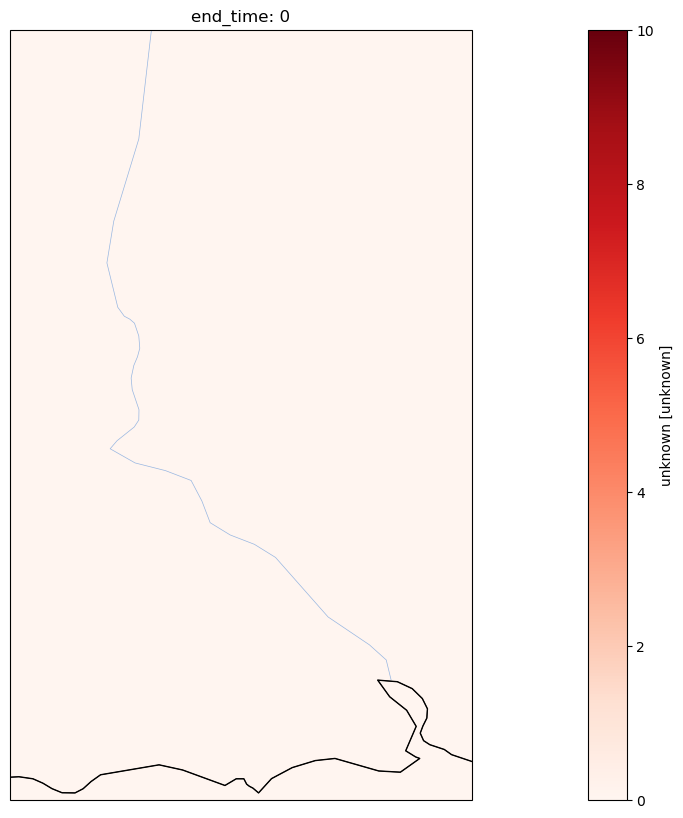

/opt/anaconda3/envs/swot/lib/python3.11/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/opt/anaconda3/envs/swot/lib/python3.11/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)


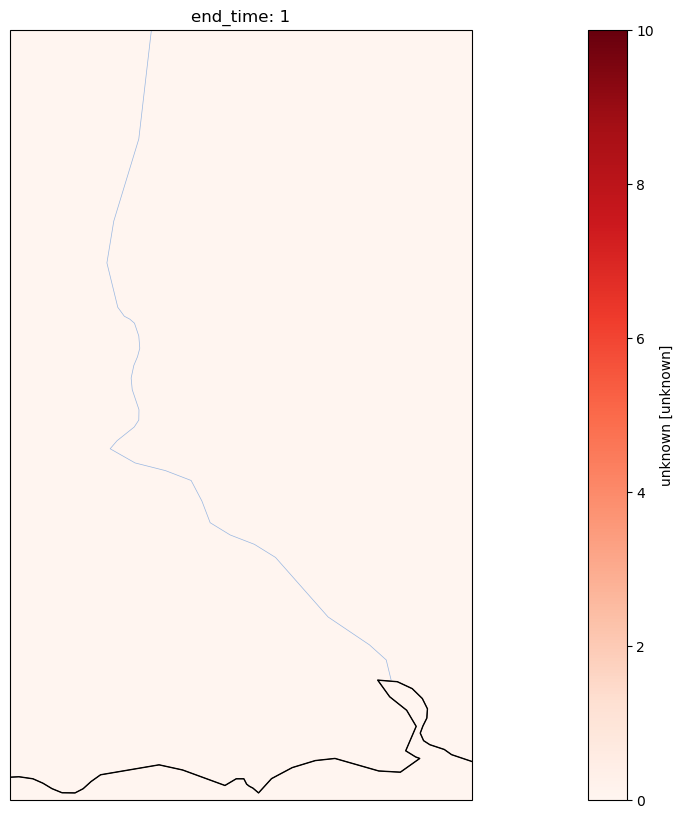

In [247]:
for i, ds in enumerate(mrmrs_data[15:17]):
    mrms_data_plot = mrmrs_data[i]
    fig = plt.figure(figsize=(30, 10))
    ax = plt.axes(projection=ccrs.PlateCarree())
    # test_data = mrmrs_data[0]
    mrms_data_plot.plot(ax=ax, transform=ccrs.PlateCarree(), vmin=0,vmax=10, cmap="Reds")
    ax.add_feature(cfeature.BORDERS, linewidth=1)
    ax.add_feature(cfeature.STATES, linewidth=0.5)
    ax.add_feature(cfeature.RIVERS, linewidth=0.5)
    ax.add_feature(cfeature.COASTLINE)
    ax.set_title("end_time: " + str(i))
    plt.show()


/opt/anaconda3/envs/swot/lib/python3.11/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/opt/anaconda3/envs/swot/lib/python3.11/site-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_physical/ne_10m_rivers_lake_centerlines.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/opt/anaconda3/envs/swot/lib/python3.11/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/opt/anaconda3/envs/swot/lib/python3.11/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)


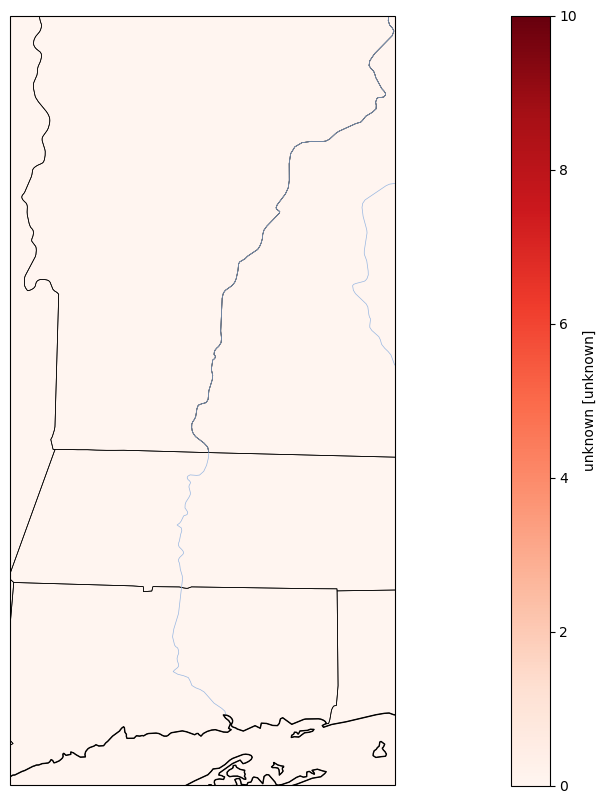

In [75]:
pd.to_datetime(ds_PIXC.illumination_time.values).tz_localize("UTC").floor("2min").max()

Timestamp('2024-08-11 23:16:00+0000', tz='UTC')

In [71]:
pd.to_datetime(ds_PIXC.illumination_time.values)

DatetimeIndex(['2024-08-11 23:17:48.266014464',
               '2024-08-11 23:17:48.266014464',
               '2024-08-11 23:17:48.266014464',
               '2024-08-11 23:17:48.266014464',
               '2024-08-11 23:17:48.266014464',
               '2024-08-11 23:17:48.266014464',
               '2024-08-11 23:17:48.266014464',
               '2024-08-11 23:17:48.266014464',
               '2024-08-11 23:17:48.266014464',
               '2024-08-11 23:17:48.266014464',
               ...
               '2024-08-11 23:17:58.270453248',
               '2024-08-11 23:17:58.270453248',
               '2024-08-11 23:17:58.270453248',
               '2024-08-11 23:17:58.270453248',
               '2024-08-11 23:17:58.270453248',
               '2024-08-11 23:17:58.270453248',
               '2024-08-11 23:17:58.270453248',
               '2024-08-11 23:17:58.270453248',
               '2024-08-11 23:17:58.270453248',
               '2024-08-11 23:17:58.270453248'],
              dtype=